<a href="https://colab.research.google.com/github/Alokathilakarathna/ME422_B3/blob/main/RIgid%20Body%20Control/e20387.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RIgid Body Control

**Task 1**

The following figures shows a 2D model of the Twin motor system in two different views.

Credits goes to instuctor in charge Mr. Bhashitha

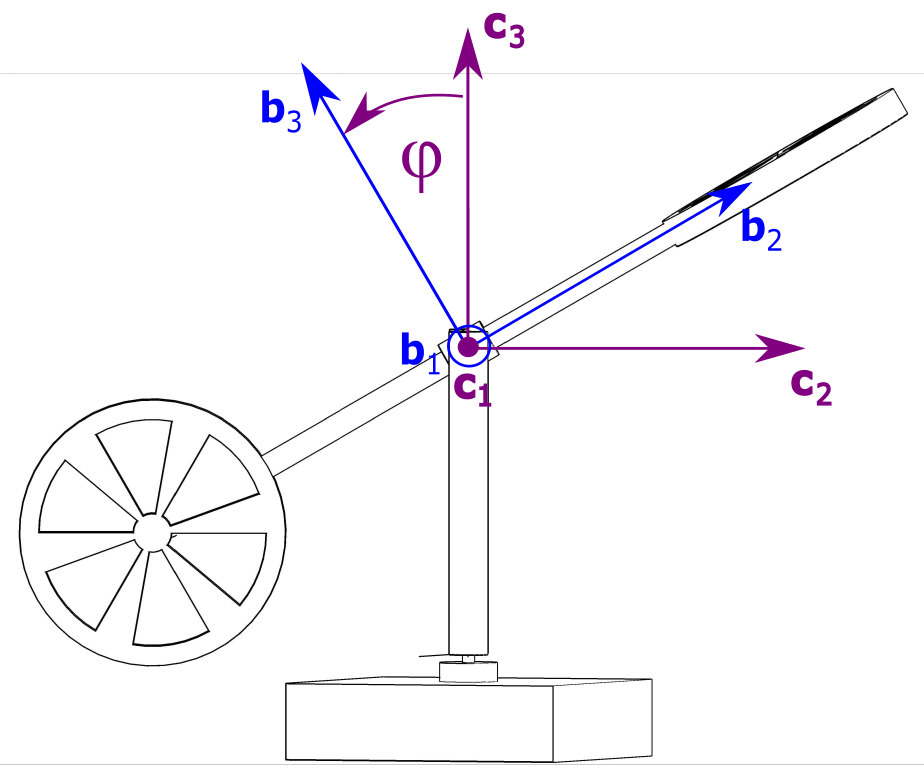

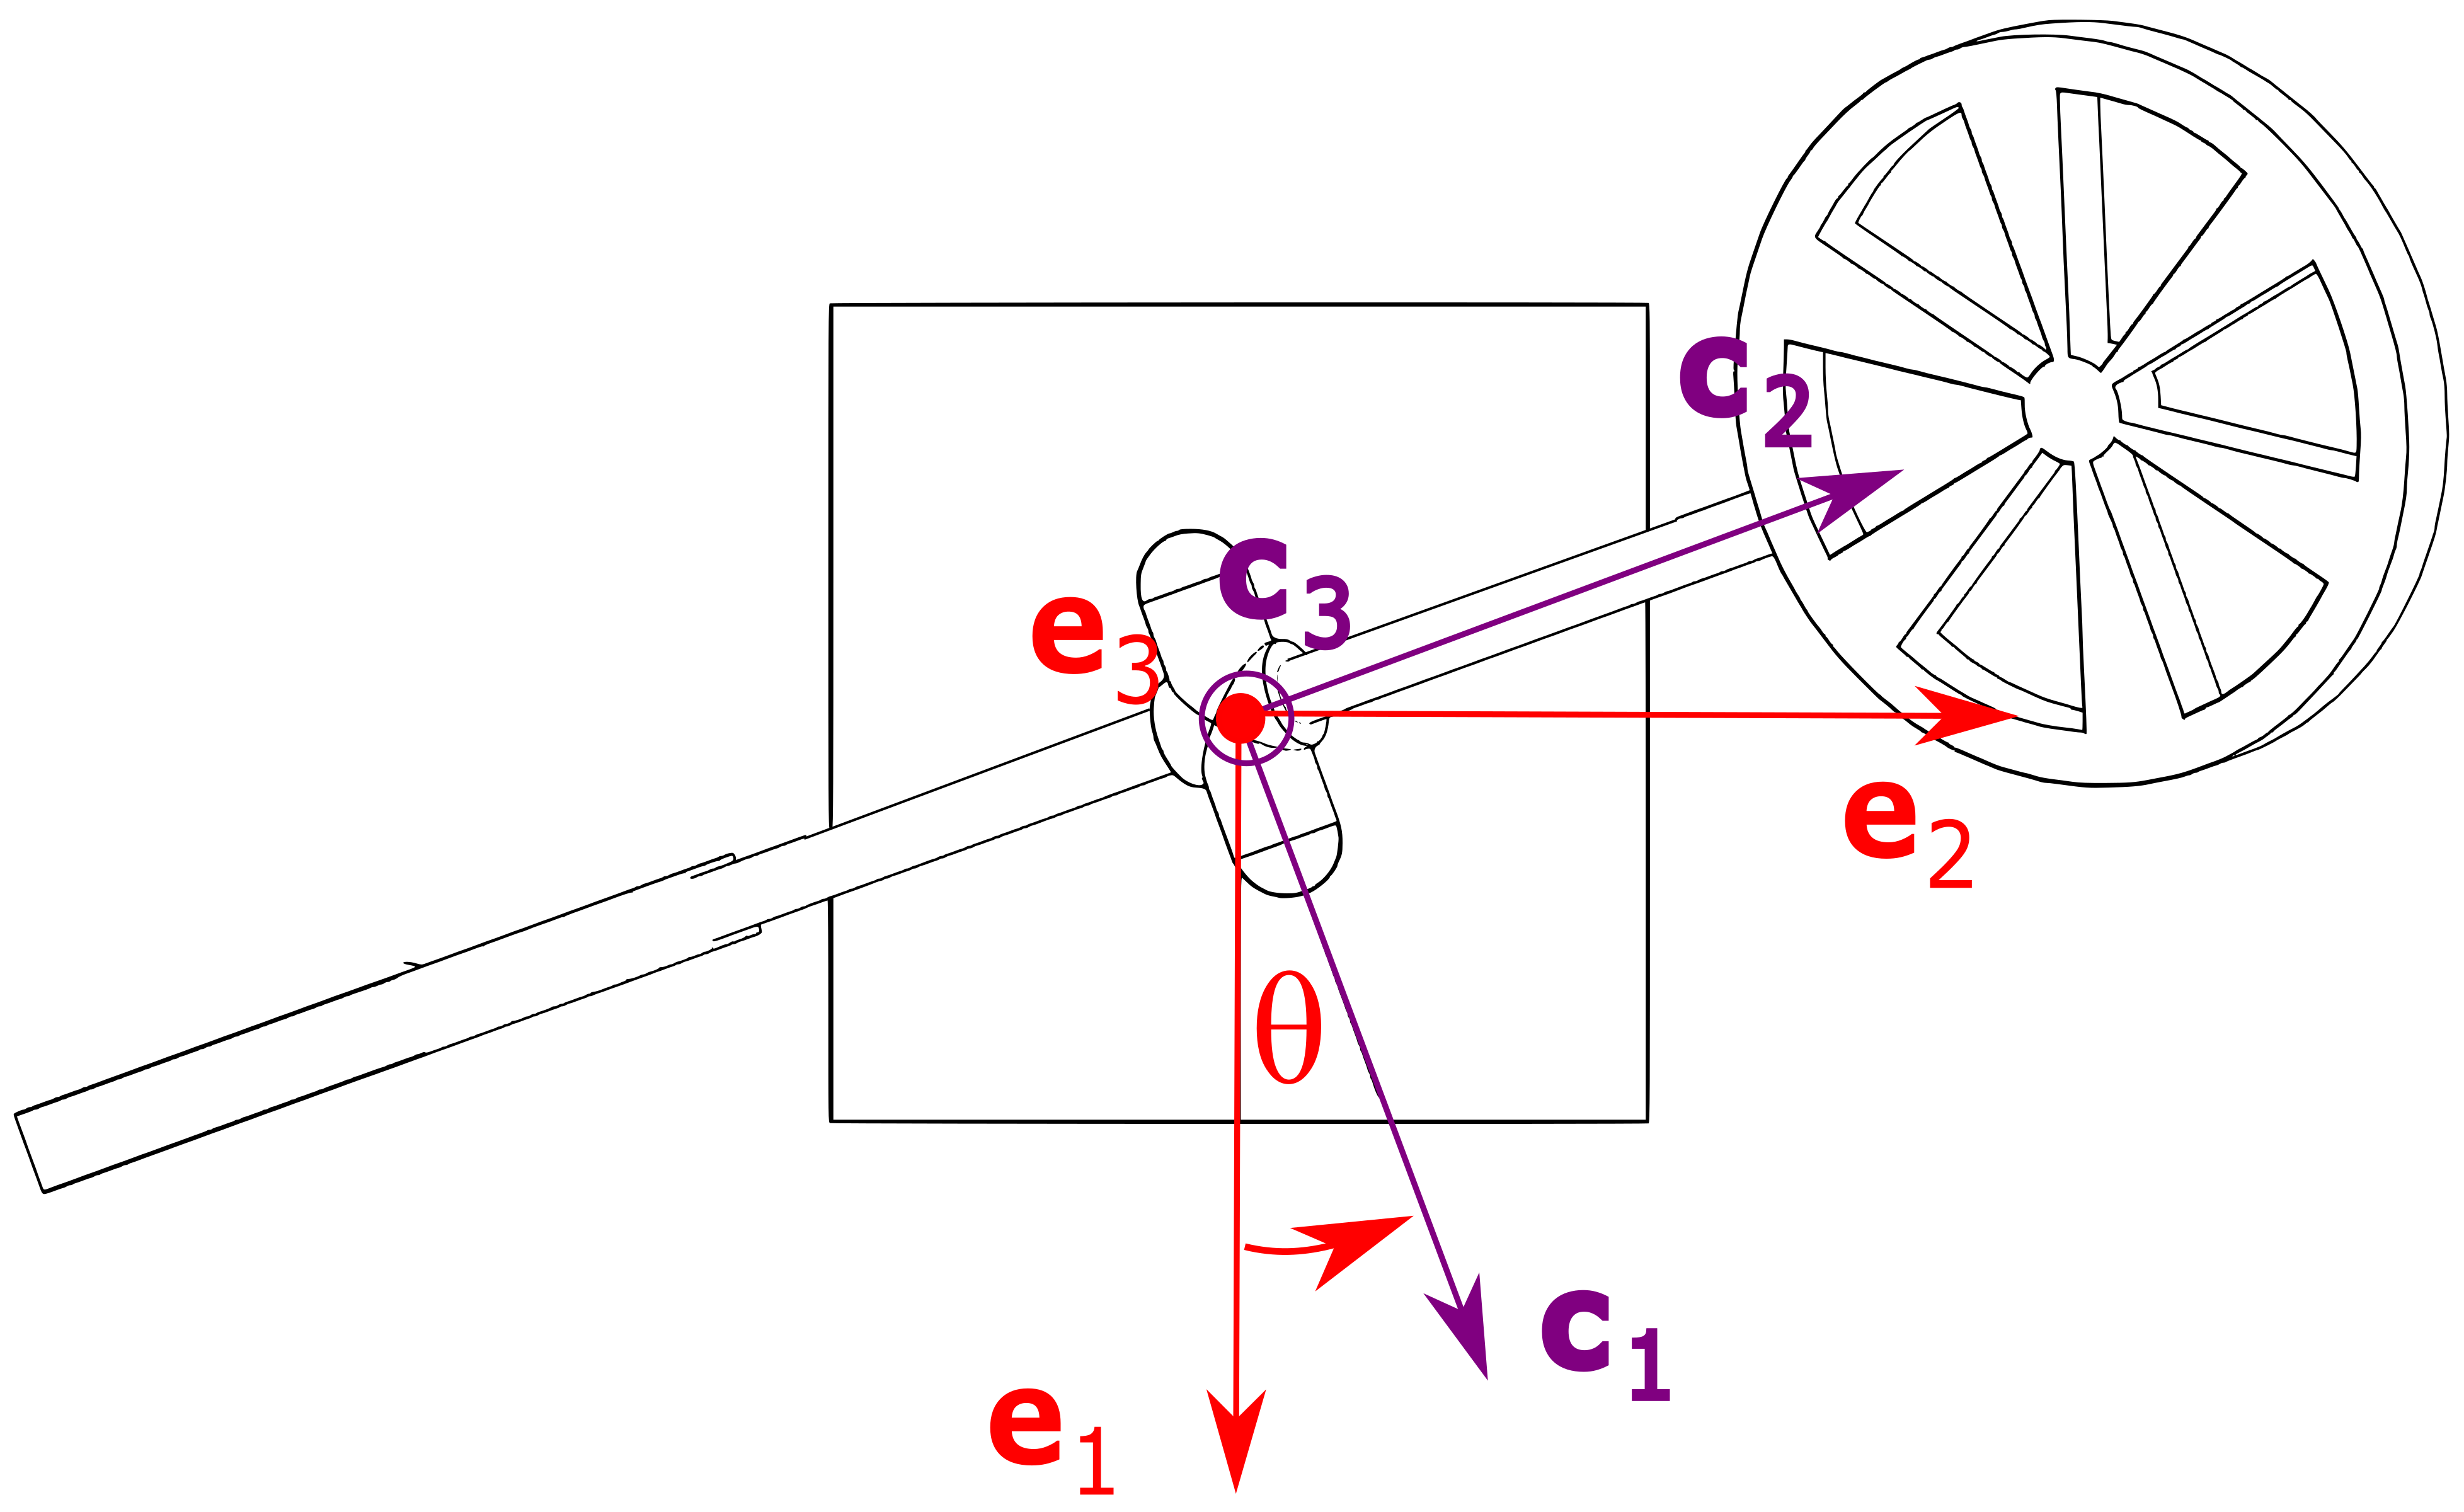

Let E and C be two orthogonal inertial frames. The two frames move respect to each other such a way, e3 and c3 axis moves always together.

$$c = eR_3(\theta)$$

$$ R_3(\theta) = \begin{pmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{pmatrix} $$

Let B and C be two orthogonal inertial frames. The two frames move respect to each other such a way, b1 and c1 axis moves always together.

$$b = cR_1(\phi)$$

$$ R_1(\phi) = \begin{pmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{pmatrix} $$

Therefore,

$$b = cR_1(\phi)$$
$$b = eR_3(\theta)R_1(\phi)$$
$$b=eR$$

Hence,

$$R=R_1(\phi)R_3(\theta)$$

$$\dot{R}=\dot{R_1}R_3+R_1\dot{R_3}$$
$$\dot{R}=R_1\hat{\Omega_1}R_3+R_1R_3\hat{\Omega_3}$$
$$\dot{R}=R\hat{\Omega}$$

$$\Omega=R_3^T\hat{\Omega}_1R_3+\hat{\Omega}_3$$

\begin{align*}
\Omega&=\dot{\phi}R_3^T(\theta)\:e_1+\dot{\theta}\:e_3,\\
&= \begin{bmatrix}
\dot{\phi}\cos{(\theta)}\\
-\dot{\phi}\sin{(\theta)}\\
\dot{\theta}
\end{bmatrix}
\end{align*}


The angular momentum in $\mathbf{e}$ is
\begin{align}
\pi&=R\mathbb{I}\Omega
\end{align}

The aqctuation moments,

\begin{align*}
\tau_u &=RT_u=R\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
\end{align*}

Thus for the controls to be implementable $T_u^Te_2=0$

\begin{align*}
\tau_u &=RT_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}\\
&=R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix}
\end{align*}

Equations of motion,

\begin{align*}
\dot{R}=\widehat{\omega}R\\
\pi=R\mathbb{I}R^T\omega\\
\dot{\pi}=RT_u=\tau_u+\tau_e
\end{align*}

Therefore, the twin rotor system shown above can be modelled by the above equations.

**Task 2**


In [4]:
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"

import numpy as np
import scipy as sp
from scipy.integrate import odeint
import math
from numpy import linalg
try:
    from rigid_body_sim import sims
except ImportError:
    import sims

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
myobject = sims.RigidBodySim()

In [6]:
def externalForceModel(qq, parameters, X):
    R = X[0][0] # Current Rotation Matrix
    M = parameters['M']
    g = parameters['g']
    CM = parameters['CM']
    F_gravity = np.array([0, 0, -M*g])
    taue = qq.hat_matrix(R @ CM) @ F_gravity

    fe = np.array([0, 0, 0])
    return [taue, fe]

def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    alpha = parameters['alpha']
    beta = parameters['beta']
    mode = parameters.get('mode', 'default')

    # Define Inputs (u1, u2)
    if mode == 'spin':
        u1 = 2.5
        u2 = 2.5
    elif mode == 'swing':
        u1 = 2.0 + 1.5 * np.sin(2 * t)
        u2 = 2.0 + 1.5 * np.sin(2 * t)
    else:
        u1 = 0.0
        u2 = 0.0

    Tx = u1 * np.cos(alpha) - u2 * np.cos(beta)
    Tz = u1 * np.sin(alpha) - u2 * np.sin(beta)

    tauu = R @ np.array([Tx, 0, Tz])

    fu = np.array([0, 0, 0])
    return [tauu, fu]

# Register models with simulator
myobject.set_external_force_model(externalForceModel)
myobject.set_actuator(actuator)

cubeDimensions = {
    'l': 4., 'w': 2, 'h': 1,
    'xp': 2., 'yp': 1., 'zp': 0.5
}

parameters = {
    'M': 2.0, 'g': 9.81,
    'CM': np.array([
        cubeDimensions['l']/2 - cubeDimensions['xp'],
        cubeDimensions['w']/2 - cubeDimensions['yp'],
        cubeDimensions['h']/2 - cubeDimensions['zp']
    ]),
    'alpha': 0.0,
    'beta': 0.0
}

ICq = myobject.q_from_axis_angles(0., np.array([1, 0, 0]))
ICR = myobject.r_from_quaternions(ICq)
ICs = [
    [ICR, np.array([0., 0., 0.])],
    np.array([0., 0., 0.]),
    np.array([0., 0., 0.]),
    np.array([0., 0., 0.])
]

parameters['alpha'] = np.pi / 6  # 30
parameters['beta'] = -np.pi / 6  # -30
parameters['mode'] = 'spin'

traj_spin = myobject.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
fig_spin = myobject.animated_cube_flat_shading(traj_spin, 'Spin at Vertical Axis ')
fig_spin.show()


parameters['alpha'] = 0.0
parameters['beta'] = 0.0
parameters['mode'] = 'swing'


traj_swing = myobject.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
fig_swing = myobject.animated_cube_flat_shading(traj_swing, 'Swing at Horizontal Axis ')
fig_swing.show()

In [9]:
newobject = sims.RigidBodySim()
cubeDimensions = {
    'l': 4.,    'w': 0.5,   'h': 0.2,
    'xp': 2.,   'yp': 0.25, 'zp': 0.1
}

parameters = {
    'M': 2.0,    'g': 9.81,
    'CM': np.array([
        cubeDimensions['l']/2 - cubeDimensions['xp'],
        cubeDimensions['w']/2 - cubeDimensions['yp'],
        cubeDimensions['h']/2 - cubeDimensions['zp']
    ]),
    'alpha': 0.0, 'beta': 0.0
}
def externalForceModel(qq, parameters, X):
    R = X[0][0]
    M = parameters['M']
    g = parameters['g']
    CM = parameters['CM']

    force_gravity = np.array([0, 0, -M*g])

    taue = qq.hat_matrix(R @ CM) @ force_gravity

    fe = np.array([0, 0, 0])
    return [taue, fe]

newobject.set_external_force_model(externalForceModel)

def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    alpha = parameters.get('alpha', 0.0)
    beta = parameters.get('beta', 0.0)
    mode = parameters.get('mode', 'swing')

    if mode == 'spin':
        u1 = 0.5
        u2 = 0.5
    else:
        u1 = 1.0 + 0.8 * np.sin(2 * t)
        u2 = 1.0 + 0.8 * np.sin(2 * t)

    Tx = u1 * np.cos(alpha) - u2 * np.cos(beta)
    Tz = u1 * np.sin(alpha) - u2 * np.sin(beta)

    T_body = np.array([Tx, 0, Tz])
    tauu = R @ T_body
    fu = np.array([0, 0, 0])

    return [tauu, fu]

newobject.set_actuator(actuator)

parameters['alpha'] = np.pi / 6  # 30 degrees tilt
parameters['beta'] = -np.pi / 6  # -30 degrees tilt
parameters['mode'] = 'spin'

ICq = newobject.q_from_axis_angles(0., np.array([1, 0, 0]))
ICR = newobject.r_from_quaternions(ICq)
ICs = [[ICR, np.array([0., 0., 0.])], np.array([0., 0., 0.]), np.array([0., 0., 0.]), np.array([0., 0., 0.])]

traj_spin = newobject.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
fig_spin = newobject.animated_cube_flat_shading(traj_spin, 'Spin at Vertical Axis ')
fig_spin.show()

parameters['alpha'] = 0.0
parameters['beta'] = 0.0
parameters['mode'] = 'swing'

ICs = [[ICR, np.array([0., 0., 0.])], np.array([0., 0., 0.]), np.array([0., 0., 0.]), np.array([0., 0., 0.])]

traj_swing = newobject.simulating_a_cube(0.05, 10., cubeDimensions, parameters, ICs)
fig_swing = newobject.animated_cube_flat_shading(traj_swing, 'Swing at Horizontal Axis')
fig_swing.show()

**Task 3**

Let $R_r(t)$ be a desired trajectory and $\omega_r(t)$ be such that $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$. In line with the system define the reference spatial angular momentum $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$

Define the configurarion error
\begin{align}
R_e&=R_rR^T.
\end{align}
Then the spatial angular velcity of the tracking error is defined by
\begin{align}
\widehat{\omega}_e&\triangleq \dot{R}_eR_e^T=\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T
\end{align}
and hence that
\begin{align}
\omega_e&=\omega_r-R_e\omega.
\end{align}
Define the angular momentum error as
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e=R\mathbb{I}R_r^T(\omega_r-R_e\omega)=R\mathbb{I}R_r^T\omega_r-R\mathbb{I}R^T\omega=R_e^T\pi_r-\pi.
\end{align}


Differentiating $\pi_e$ we have
\begin{align}
\dot{\pi}_e&=R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}=R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}=(R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}
\end{align}



Thus we have the error dynamics
\begin{align}
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{\pi}_e&=(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e
\end{align}

**Task 3: Trajectory Tracking Control Design**

1. Configuration Error Definitions


We define the errors between the current system configuration $R$ and the reference configuration $R_r(t)$.

* **Configuration Error ($R_e$):**
    The error is defined in the configuration space $SO(3)$ as:
    $$R_e \triangleq R_r R^T$$

* **Spatial Angular Velocity Error ($\omega_e$):**
    Let $\hat{\omega}_r = \dot{R}_r R_r^T$. The tracking error velocity is defined by:
    $$\hat{\omega}_e \triangleq \dot{R}_e R_e^T = \hat{\omega}_r - R_e \hat{\omega} R_e^T$$
    This simplifies to the vector form:
    $$\omega_e = \omega_r - R_e \omega$$

* **Spatial Momentum Error ($\pi_e$):**
    Defined based on the momentum in the reference frame:
    $$\pi_e \triangleq R \mathbb{I} R_r^T \omega_e = R \mathbb{I} R_r^T (\omega_r - R_e \omega)$$
    This expands to:
    $$\pi_e = R_e^T \pi_r - \pi$$
    where $\pi_r \triangleq R_r \mathbb{I} R_r^T \omega_r$ is the reference spatial angular momentum.



 2. Error Dynamics
Differentiating the error terms yields the system dynamics used for control design.

* **Orientation Error Dynamics:**
    $$\dot{R}_e = \hat{\omega}_e R_e$$

* **Momentum Error Dynamics:**
    Differentiating $\pi_e$ and substituting the equations of motion $\dot{\pi} = \tau_u + \tau_e$:
    $$\dot{\pi}_e = (R \dot{\Pi}_r + \omega \times \pi_r) - \tau_u - \tau_e$$



3. Feedforward plus PID Control Law
To ensure asymptotic tracking ($R \to R_r$), we design a control law $\tau_u$ that cancels the known dynamics (feedforward) and stabilizes the error (feedback).

* **Control Law ($\tau_u$):** $\tau_u = -\tau_e + (R \dot{\Pi}_r + \omega \times \pi_r) + k_{P_R} e_R + k_{D_R} \pi_e + k_{I_R} e_{I_R}$

    Where:
    * **Feedforward Term:** $(R \dot{\Pi}_r + \omega \times \pi_r)$ handles the reference trajectory dynamics.
    * **Constraint Compensation:** $-\tau_e$ cancels the external constraint moments.
    * **Proportional Error Vector ($e_R$):**
        Let $K = \text{diag}\{k_1, k_2, k_3\}$ be a gain matrix. The error vector $e_R$ is derived from the skew-symmetric part of the error:
        $$\hat{e}_R = \frac{1}{2} (R_e K - K R_e^T)$$
    * **Integral Error ($e_{I_R}$):**
        $$\dot{e}_{I_R} = e_R$$

* **Implementation Constants:**
    $k_{P_R}, k_{D_R}, k_{I_R}$ are the scalar tuning gains for the Proportional, Derivative, and Integral terms respectively.



4. Actuation Implementation
For the simulation, we map the calculated control torque $\tau_u$ to the physical motor inputs.

Using the relation $T_u = R^T \tau_u$, and assuming $\alpha = \beta$:
$$T_u = \begin{bmatrix} (u_1 - u_2) \cos\alpha \\ 0 \\ (u_1 - u_2) \sin\alpha \end{bmatrix}$$

We solve for the control inputs $u_{diff} = (u_1 - u_2)$ and tilt angle $\alpha$:
$$u_{diff} = \sqrt{(e_1^T T_u)^2 + (e_3^T T_u)^2}$$
$$\tan(\alpha) = \frac{e_3^T T_u}{e_1^T T_u}$$